<a href="https://colab.research.google.com/github/iris-hep/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_3_parameterized_carl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## ============================================================================
# Google Colab setup — run me first.  Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/iris-hep/nsbi-lhc-toolkit.git"  # package + tutorial helpers
BRANCH   = "ml4hep_school_tutorial"
N_BKG, N_SIG = 1_000_000, 1_000_000     # Colab-sized dataset (raise for less MC noise in the fit)
USE_DRIVE = False                    # True -> save data/models to Google Drive so they
                                    # persist across notebooks & sessions (see notes above)
# ----------------------------------------------------------------------------

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = "/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab"
    else:
        ROOT = "/content"
    os.makedirs(ROOT, exist_ok=True)
    os.chdir(ROOT)

    # 1) fetch ONLY the package source + tutorial helpers (skip Git-LFS / big blobs)
    if not os.path.isdir("nsbi-lhc-toolkit"):
        os.environ["GIT_LFS_SKIP_SMUDGE"] = "1"
        !git clone --depth 1 --filter=blob:none --sparse --branch $BRANCH $REPO_URL
        !cd nsbi-lhc-toolkit && git sparse-checkout set src workshops/ml4hep_tifr_colab

    # 2) make `import nsbi_common_utils` work (pure-python src layout, no build step)
    src = os.path.abspath("nsbi-lhc-toolkit/src")
    if src not in sys.path:
        sys.path.insert(0, src)

    # 3) runtime deps Colab doesn't already ship (torch/jax/sklearn/... are preinstalled)
    !pip install -q pytorch-lightning onnx onnxruntime onnxscript iminuit mplhep

    # 4) work from the tutorial dir so utils.py / generate_distributions.py and the
    #    ./dataframes, ./models_* relative paths resolve just like a local run
    os.chdir("nsbi-lhc-toolkit/workshops/ml4hep_tifr_colab")

    # 5) generate the Gaussian-mixture samples if they aren't there yet
    if not os.path.exists("dataframes/signal.parquet"):
        !python generate_distributions.py --n_bkg $N_BKG --n_sig $N_SIG

print("Working dir:", os.getcwd())

Working dir: /Users/jaysandesara/Documents/NSBI-workflow-tutorial/workshops/ml4hep_tifr_colab


Parameterized CARL vs. morphing
---

In Exercise 2 we trained **two fixed density ratios** — signal-vs-reference and background-vs-reference — and the parametric model then **morphs** them across the POI $\mu$ with the closed-form combination

$$R_\psi(x\mid\mu) = \frac{p(x\mid\mu)}{p_\mathrm{ref}(x)} = \frac{\mu\,\lambda_\mathrm{sig}\,\frac{p_\mathrm{sig}(x)}{p_\mathrm{ref}(x)} + \lambda_\mathrm{bkg}\,\frac{p_\mathrm{bkg}(x)}{p_\mathrm{ref}(x)}}{\mu\,\lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} = \frac{\mu\,\lambda_\mathrm{sig}\,R_\psi^\mathrm{sig}(x) + \lambda_\mathrm{bkg}\,R_\psi^\mathrm{bkg}(x)}{\mu\,\lambda_\mathrm{sig} + \lambda_\mathrm{bkg}}.$$

Here we instead train **one network**, conditioned on $\mu$, whose output is the **classifier score**

$$q_\psi(x;\mu) \;=\; q_\psi(y=1\mid x,\mu)\in(0,1).$$

Following the density-ratio-via-classification trick (see the lecture slides), the ratio is *not* regressed directly — it is **recovered from the score**

$$R_\psi(x\mid\mu) \;=\; \frac{q_\psi(x;\mu)}{1-q_\psi(x;\mu)} \;\approx\; \frac{p(x\mid\mu)}{p_\mathrm{ref}(x)},$$

a **parameterized CARL** estimator. Both approaches target the **same** ratio against the **same** reference $p_\mathrm{ref}=\mathrm{concat}(\text{background},\text{signal})$ (the denominator used in 2a/2b), so we can put them side-by-side against the analytic truth.

In [16]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import mplhep as hep
from sklearn.preprocessing import StandardScaler

import nsbi_common_utils
from nsbi_common_utils.training.utils import load_trained_model
from utils import (split_train_inference, mixture_density,
                   signal_components, background_components,
                   smearing_parameters)

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cpu


Load the same dataset used throughout the exercises.

In [32]:
BASE_PATH = "./dataframes/"
signal = pd.read_parquet(f"{BASE_PATH}/signal.parquet")
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

FEATURES = ["x1", "x2", "x3", "x4", "x5"]
POI_RANGE = (0.0, 10.0)          # uniform prior / test range for mu

### Train / inference split

Same convention as Exercise 2: **train on the training half**, evaluate the ratios on the disjoint **inference half**. `split_train_inference` rescales each half's weights back to the full expected yield, so $\lambda_\mathrm{sig},\lambda_\mathrm{bkg}$ are unchanged.

In [33]:
SPLIT_SEED, TRAIN_FRACTION = 0, 0.5
sig_tr, sig_inf = split_train_inference(signal, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)
bkg_tr, bkg_inf = split_train_inference(background, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)

lam_S = float(sig_tr.weight.sum())   # signal yield  (~1.1e3)
lam_B = float(bkg_tr.weight.sum())   # background yield (~1e6)
print(f"lambda_sig = {lam_S:.4g}   lambda_bkg = {lam_B:.4g}   S/B = {lam_S/lam_B:.2e}")

lambda_sig = 1100   lambda_bkg = 1e+06   S/B = 1.10e-03


## 1. Morph the mixture for uniformly sampled $\mu$

The per-event density at signal strength $\mu$ is the **morph** of the two templates,

$$p(x\mid\mu) = \frac{\mu\,\lambda_\mathrm{sig}\,p_\mathrm{sig}(x) + \lambda_\mathrm{bkg}\,p_\mathrm{bkg}(x)}{\mu\,\lambda_\mathrm{sig} + \lambda_\mathrm{bkg}}.$$

We build the CARL training set as **numerator = mixture at $\mu$** vs **denominator = reference $p_\mathrm{ref}$**:

* **Numerator** ($y=1$): all signal + background events, each given a fresh $\mu_e\sim\mathrm{Uniform}(0,10)$ and weight
  $w^\mathrm{num}_e = \dfrac{\mu_e\,w_e}{\mu_e\lambda_\mathrm{sig}+\lambda_\mathrm{bkg}}$ (signal) or $\dfrac{w_e}{\mu_e\lambda_\mathrm{sig}+\lambda_\mathrm{bkg}}$ (background).
  The division by $\mu_e\lambda_\mathrm{sig}+\lambda_\mathrm{bkg}$ normalises each $\mu$-slice to unit mass, so there is **no $\mu$-dependent drift** in the learned ratio.
* **Denominator** ($y=0$): the reference sample $\mathrm{concat}(\text{background},\text{signal})$ with its physics weights, each given a fresh $\mu_e$ (independent of $x$) so the network sees $\mu$ under both classes and cannot cheat.

At the optimum the classifier score satisfies $\dfrac{q_\psi(x;\mu)}{1-q_\psi(x;\mu)}=\dfrac{p(x\mid\mu)}{p_\mathrm{ref}(x)}=R_\psi(x\mid\mu)$ — exactly the morphed target.

In [ ]:
rng = np.random.default_rng(0)

# ---- numerator: mixture at per-event mu (signal scaled by mu) ----
num_x      = np.vstack([sig_tr[FEATURES].values, bkg_tr[FEATURES].values]).astype(np.float32)
num_is_sig = np.concatenate([np.ones(len(sig_tr)), np.zeros(len(bkg_tr))]).astype(bool)
num_wphys  = np.concatenate([sig_tr.weight.values, bkg_tr.weight.values])
mu_num     = rng.uniform(*POI_RANGE, size=len(num_x))
norm_num   = mu_num * lam_S + lam_B
w_num      = np.where(num_is_sig, mu_num * num_wphys, num_wphys) / norm_num

# ---- denominator: reference = concat(background, signal), fresh mu draws ----
den_x     = np.vstack([bkg_tr[FEATURES].values, sig_tr[FEATURES].values]).astype(np.float32)
den_wphys = np.concatenate([bkg_tr.weight.values, sig_tr.weight.values])
mu_den    = rng.uniform(*POI_RANGE, size=len(den_x))
w_den     = den_wphys / (lam_S + lam_B)

# ---- stack, subsample (training on a manageable size), shuffle ----
X   = np.vstack([num_x, den_x])
mu  = np.concatenate([mu_num, mu_den]).astype(np.float32)
w   = np.concatenate([w_num, w_den]).astype(np.float64)
y   = np.concatenate([np.ones(len(num_x)), np.zeros(len(den_x))]).astype(np.float32)

N_TRAIN = 1_000_000                       # cap total rows (raise if you have a GPU)
if len(y) > N_TRAIN:
    keep = rng.permutation(len(y))[:N_TRAIN]
    X, mu, w, y = X[keep], mu[keep], w[keep], y[keep]

# per-class weight normalisation (balanced BCE) + log-normalisation offset
m1, m0 = y == 1, y == 0
wsum1, wsum0 = w[m1].sum(), w[m0].sum()
w_bal = w.copy()
w_bal[m1] *= 0.5 / wsum1
w_bal[m0] *= 0.5 / wsum0
print(f"{m1.sum():,} numerator + {m0.sum():,} reference")

500,028 numerator + 499,972 reference   log_norm_offset = +0.0003


### Preprocess features and build tensors

Standardise the observables (fit on training data), scale $\mu$ into $[0,1]$, and concatenate $\mu$ as an extra input column: the network input is $(x_1,\dots, x_5,\ \mu)$.

In [35]:
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X).astype(np.float32)
mu_scaled = (mu / POI_RANGE[1]).reshape(-1, 1).astype(np.float32)
feat = np.concatenate([Xs, mu_scaled], axis=1)

feat_t = torch.from_numpy(feat)
y_t    = torch.from_numpy(y)
w_t    = torch.from_numpy(w_bal.astype(np.float32))

# train / validation split
n = len(y_t)
perm = torch.randperm(n)
n_val = int(0.2 * n)
val_idx, tr_idx = perm[:n_val], perm[n_val:]

## 2. Train the parameterized CARL

A plain MLP (SiLU activations) whose **sigmoid output is the classifier score** $q_\psi(x;\mu)=q_\psi(y=1\mid x,\mu)$, trained with the **weight-balanced binary cross-entropy** $\mathcal{L}_\mathrm{BCE}$ — the CARL loss. The density ratio is then read off from the score as

$$R_\psi(x\mid\mu)=\frac{q_\psi(x;\mu)}{1-q_\psi(x;\mu)} $$

In [ ]:
class ParamCARL(nn.Module):
    def __init__(self, n_in, hidden=(1024, 1024, 1024)):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.SiLU()]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # classifier score s = q_psi(y=1 | x, mu) in (0, 1)
        return torch.sigmoid(self.net(x).squeeze(-1))


model = ParamCARL(feat.shape[1]).to(DEVICE)
opt = torch.optim.NAdam(model.parameters(), lr=1e-3)
bce = nn.BCELoss(reduction="none")          # plain BCE on the score s (no logits)

EPOCHS, BATCH = 50, 1024
tr_feat, tr_y, tr_w = feat_t[tr_idx].to(DEVICE), y_t[tr_idx].to(DEVICE), w_t[tr_idx].to(DEVICE)
va_feat, va_y, va_w = feat_t[val_idx].to(DEVICE), y_t[val_idx].to(DEVICE), w_t[val_idx].to(DEVICE)

for epoch in range(EPOCHS):
    model.train()
    order = torch.randperm(len(tr_y), device=DEVICE)
    for i in range(0, len(order), BATCH):
        b = order[i:i + BATCH]
        opt.zero_grad()
        loss = (bce(model(tr_feat[b]), tr_y[b]) * tr_w[b]).sum() / tr_w[b].sum()
        loss.backward()
        opt.step()
    model.eval()
    with torch.no_grad():
        vl = (bce(model(va_feat), va_y) * va_w).sum() / va_w.sum()
    print(f"Epoch {epoch:3d}  train_loss={loss.item():.5f}  val_loss={vl.item():.5f}", flush=True)

Epoch   0  train_loss=0.69145  val_loss=0.69429
Epoch   1  train_loss=0.69220  val_loss=0.69428
Epoch   2  train_loss=0.69143  val_loss=0.69473
Epoch   3  train_loss=0.69313  val_loss=0.69333
Epoch   4  train_loss=0.69324  val_loss=0.69330
Epoch   5  train_loss=0.69331  val_loss=0.69338
Epoch   6  train_loss=0.69304  val_loss=0.69318
Epoch   7  train_loss=0.69312  val_loss=0.69331
Epoch   8  train_loss=0.69165  val_loss=0.69412
Epoch   9  train_loss=0.69240  val_loss=0.69332
Epoch  10  train_loss=0.69204  val_loss=0.69339
Epoch  11  train_loss=0.69329  val_loss=0.69315
Epoch  12  train_loss=0.69038  val_loss=0.69450
Epoch  13  train_loss=0.69313  val_loss=0.69315
Epoch  14  train_loss=0.69417  val_loss=0.69314
Epoch  15  train_loss=0.69317  val_loss=0.69316
Epoch  16  train_loss=0.69295  val_loss=0.69317
Epoch  17  train_loss=0.69386  val_loss=0.69320
Epoch  18  train_loss=0.69320  val_loss=0.69317
Epoch  19  train_loss=0.69293  val_loss=0.69316
Epoch  20  train_loss=0.69337  val_loss=

In [ ]:
def carl_score(x_feats, mu_vals):
    # classifier score s = q_psi(y=1 | x, mu) 
    xs = scaler.transform(np.asarray(x_feats, dtype=np.float32))
    ms = (np.asarray(mu_vals, dtype=np.float32) / POI_RANGE[1]).reshape(-1, 1)
    inp = torch.from_numpy(np.concatenate([xs, ms], axis=1).astype(np.float32)).to(DEVICE)
    model.eval()
    with torch.no_grad():
        return model(inp).cpu().numpy()


def carl_ratio(x_feats, mu_vals):
    # convert the score to a density ratio:  r = s / (1 - s)
    s = carl_score(x_feats, mu_vals)
    return s / (1.0 - s)

## 3. The morphed model and the truth

* **Truth**: analytic densities from `utils`, combined with the exact morphing formula.
* **Morphed (Exercise 2 style)**: the two *fixed* trained ratios $R_\psi^\mathrm{sig},R_\psi^\mathrm{bkg}$ from 2a/2b, combined with the same formula. Falls back to the truth ratios if the trained models are not on disk.

In [ ]:
def reco_components_from_truth_components(components):
    # smear truth-level (z) Gaussian components into reco (x) space:
    #   x = scale * z + N(0, resolution^2)  =>  mean_x = scale*mean_z,
    #   cov_x = D Sigma_z D^T + diag(resolution^2),  with  D = diag(scale)
    scale, resolution = smearing_parameters()
    scale = np.asarray(scale, dtype=float)
    resolution = np.asarray(resolution, dtype=float)
    D = np.diag(scale)
    response_cov = np.diag(resolution ** 2)
    return [
        (frac, scale * np.asarray(mean_z, dtype=float),
         D @ np.asarray(cov_z, dtype=float) @ D.T + response_cov)
        for frac, mean_z, cov_z in components
    ]


SIG_RECO = reco_components_from_truth_components(signal_components())
BKG_RECO = reco_components_from_truth_components(background_components())


def morph(rS, rB, mu, lam_S=lam_S, lam_B=lam_B):
    # closed-form morphing of two fixed ratios to signal strength mu
    return (mu * lam_S * rS + lam_B * rB) / (mu * lam_S + lam_B)

def truth_ratios(X):
    p_S = mixture_density(X, SIG_RECO)
    p_B = mixture_density(X, BKG_RECO)
    p_ref = (lam_B * p_B + lam_S * p_S) / (lam_B + lam_S)
    return p_S / p_ref, p_B / p_ref          

def nn_ratios(X):
    try:
        sc_S, m_S = load_trained_model("models_SigvsRef/model0.onnx", "models_SigvsRef/model_scaler0.bin")
        sc_B, m_B = load_trained_model("models_BkgvsRef/model0.onnx", "models_BkgvsRef/model_scaler0.bin")
        Xf = pd.DataFrame(X, columns=FEATURES).astype("float32")
        rS = nsbi_common_utils.training.utils.predict_with_model(Xf, scaler=sc_S, model=m_S)
        rB = nsbi_common_utils.training.utils.predict_with_model(Xf, scaler=sc_B, model=m_B)
        return rS, rB, True
    except Exception as e:
        print("Trained 2a/2b models not found -> morphed model uses TRUTH ratios.", e)
        rS, rB = truth_ratios(X)
        return rS, rB, False

### Evaluate on held-out events with $\mu\sim\mathrm{Uniform}(0,10)$

Draw a test set from the **inference half** and assign each event a random POI value. Compute $\log R_\psi(x\mid\mu)$ three ways and plot predicted-vs-truth side-by-side.

In [44]:
N_TEST = 40_000
test_df = pd.concat([sig_inf, bkg_inf], ignore_index=True)
test_df = test_df.sample(n=min(N_TEST, len(test_df)), random_state=1).reset_index(drop=True)
X_test = test_df[FEATURES].values.astype(np.float32)

# Arbitrarily sampled POI values, one per test event (the whole point: a single
# model must be correct across the entire mu range, not at one fixed mu).
mu_test = rng.uniform(*POI_RANGE, size=len(X_test))

# log r(x | mu), three ways
rS_t, rB_t = truth_ratios(X_test)
logr_truth = np.log(morph(rS_t, rB_t, mu_test))

rS_n, rB_n, used_nn = nn_ratios(X_test)
logr_morph = np.log(morph(rS_n, rB_n, mu_test))

logr_carl = np.log(carl_ratio(X_test, mu_test))


def logr_stats(pred, truth):
    delta = pred - truth
    return {
        "corr": float(np.corrcoef(truth, pred)[0, 1]),
        "rmse": float(np.sqrt(np.mean(delta ** 2))),
        "bias": float(np.mean(delta)),
        "mse": float(np.mean(delta ** 2)),
    }

stats_morph = logr_stats(logr_morph, logr_truth)
stats_carl = logr_stats(logr_carl, logr_truth)
print(f"morphed       : corr={stats_morph['corr']:.4f}  RMSE={stats_morph['rmse']:.4f}  bias={stats_morph['bias']:+.4f}")
print(f"parameterized : corr={stats_carl['corr']:.4f}  RMSE={stats_carl['rmse']:.4f}  bias={stats_carl['bias']:+.4f}")

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


morphed       : corr=0.9372  RMSE=0.0065  bias=+0.0030
parameterized : corr=-0.1805  RMSE=0.0159  bias=+0.0034


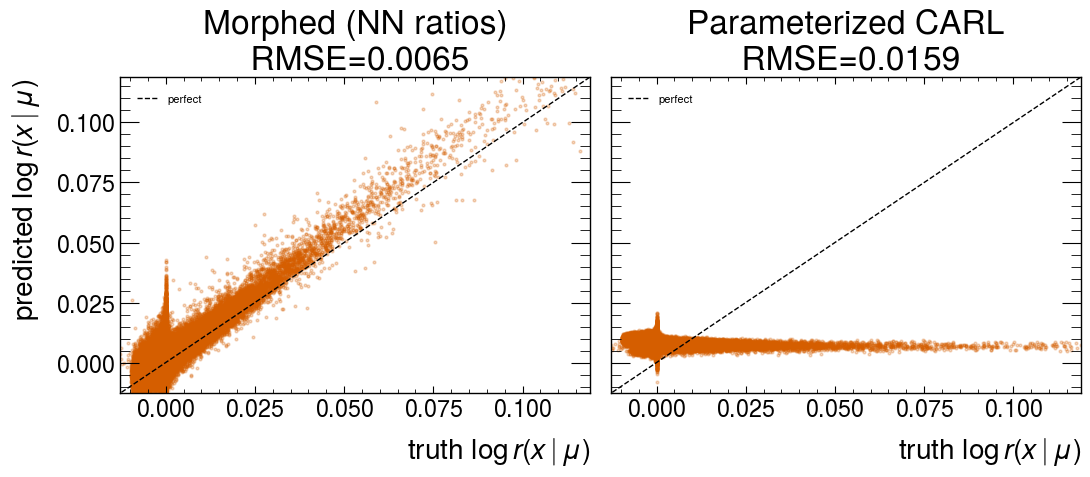

In [45]:
def parity_panel(ax, truth, pred, title, stats):
    ax.scatter(truth, pred, s=4, alpha=0.25)
    lo = min(truth.min(), pred.min())
    hi = max(truth.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect")
    ax.set_xlabel(r"truth $\log r(x\mid\mu)$")
    ax.set_title(f"{title}\n RMSE={stats['rmse']:.4f}")
    ax.legend(fontsize=8)

allv = np.concatenate([logr_truth, logr_morph, logr_carl])
lo, hi = np.percentile(allv, [0.2, 99.8])

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
parity_panel(axes[0], logr_truth, logr_morph,
             f"Morphed ({'NN' if used_nn else 'truth'} ratios)", stats_morph)
parity_panel(axes[1], logr_truth, logr_carl, "Parameterized CARL", stats_carl)
axes[0].set_xlim(lo, hi)
axes[0].set_ylim(lo, hi)
axes[0].set_ylabel(r"predicted $\log r(x\mid\mu)$")
fig.tight_layout()
plt.show()